In [ ]:
import os, sys

if not os.path.exists("sis1_group7"):
    !git clone https://github.com/BradDanAlexandru/sis1_group7.git

sys.path.insert(0, "sis1_group7")

**Lab 5: FIR Filtering 2**

The goal of this lab is to study the response of FIR filters to inputs such as complex exponentials and sinusoids. In the experiments of this lab, you will use `np.convolve()` to implement filters and `freqz()` to obtain the filter’s frequency response. As a result, you should learn how to characterize a filter by knowing how it reacts to different frequency components in the input.
This lab also introduces two practical filters: bandpass filters and nulling filters.
Bandpass filters can be used to detect and extract information from complex signals,
e.g., tones in a touch-tone telephone dialer. Nulling filters can be used to remove
sinusoidal interference, e.g., jamming signals in a radar.

In [42]:
import os
import numpy as np
import librosa
import IPython.display as ipd
from scipy import signal
import matplotlib.pyplot as plt
from IPython.display import Audio
from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram

1.1. First, let's replicate what we did until now. Copy the functions synthesize and envelope and obtain the synthesis from the last lab.

In [ ]:
def averaging_filter(x, N):
    b = np.ones(N) / N
    return np.convolve(x, b, mode='same')

def envelope(x, N):
    full_wave = np.abs(x)
    return averaging_filter(full_wave, N)

def synthesize(f0, phi, Ak, t):
    y = np.zeros_like(t, dtype=float)
    for k in range(1, len(Ak) + 1):
        y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
    return y

# Load reference audio
filepath = "audio/136954__stomachache__gsharp1.wav"
ref, fs = load_audio(filepath)

#info from previous labs
f0 = 416.037
phi = ((0.317277 - 0.31608) / 0.0024266) * 2 * np.pi
t = np.arange(len(ref)) / fs
weights = [1, 0.0264, 0.0143, 0.032, 0.005, 0.0005, 0.00095]

s = synthesize(f0, phi, weights, t)
env = envelope(ref, 150)   
synthesized = s * env

1.2 Plot both reference and synthesised signal.

In [44]:
# Write your code here
plot_signals([ref, synthesized], fs, name = ["reference signal", "synthesized signal"])

---

**2. Averaging filter**

Now let's analyze the frequency response of the average filter used in the envelope function. The Scipy Python module has a function called *freqz()* for computing the frequency
response of a discrete-time LTI system. The following Python statements show how to
use freqz to compute and plot both the magnitude (absolute value) and the phase of
the frequency response of a four-point averaging system as a function of ω in the range − π ≤ ω ≤ π :

In [45]:
from util import plot_frequency_response

ww = np.arange(-np.pi, np.pi, np.pi/500)
_, HH = signal.freqz([1/4]*4, 1, ww)

plot_frequency_response(ww, HH)

For FIR filters, the second argument of `freqz(-, 1,- )` must always be equal to 1. The frequency vector ww should cover an interval of length 2π for ω , and its spacing must be fine enough to give a smooth curve for H(ejω) . Note: we will always use capital H for the frequency response.

2.1 Use the `freqz` and `plot_frequency_response` functions to plot the frequency response of the averaging filter of your envelope function.



In [ ]:
ww = np.arange(-np.pi, np.pi, np.pi/500)
_, H = signal.freqz([1/150]*150, 1, ww) #env = envelope(ref, 150) 

plot_frequency_response(ww, H)

2.2 Looking at the frequency responses, what are the main differences between your filter and the four-point averaging filter. What happens when the value N is increased?

The main difference between the two filters is the selectivity of the magnitude response. The 150-point filter ($N=150$) has a much narrower main peak centered at zero, acting as a very aggressive low-pass filter, whereas the 4-point filter ($N=4$) has a wide main peak that allows higher frequencies to pass. As $N$ increases, the resolution in the frequency domain improves, making the passband more tight, but this also introduces significantly more little peaks in the magnitude plot.

In general, as the value of N is increased, the filter becomes a better low-pass filter and acts as a stronger smoother. However,this increments the tiem delay. The number of nulls (zeros) in the frequency response also increases

---

**3. Nulling Filters for Rejection**

Nulling filters are filters that completely eliminate some frequency components. If the frequency is $\omega=0$ or $\omega=\pi$ then a two-point FIR filter will do the nulling. The simplest possible general nulling filter can have as few as three coefficients. If $\omega_n$ is the desired nulling frequency, then the following length-3 FIR filter

$$
y[n] = x[n] - 2\cos(\omega_n)x[n-1] + x[n-2] 
$$

will have a zero in its frequency response at $\omega=\omega_n$. For example, a filter designed to completely eliminate signals of the form $e^{j0.5\pi}$ would have the following coefficients because we would pick the desired nulling frequency to be $\omega_n = 0.5\pi$

$$
b_0 = 1, \quad b1=-2cos(\omega_n)=0, \quad b_2=1
$$

3.1 Use the following function to add an interference in your reference signal. Name the corrupted signal as `x_interf`.

In [47]:
def add_interference(x, fs):
  t = np.linspace(0, len(x)*1/float(fs), len(x))
  y = x + (np.amax(x)/10)*np.sin(2*np.pi*1000*t)
  return y

In [48]:
# Write your code here
x=ref
x_interf = add_interference(x, fs)

3.2 Plot both the reference signal and the corrupted signal and listen to the latter one. 

In [49]:
# Write your code here
plot_signals([ref, x_interf ], fs, name = ["reference signal", "corrupted signal"])

3.3 Compare the spectrograms of the reference signal and the interference signal. 

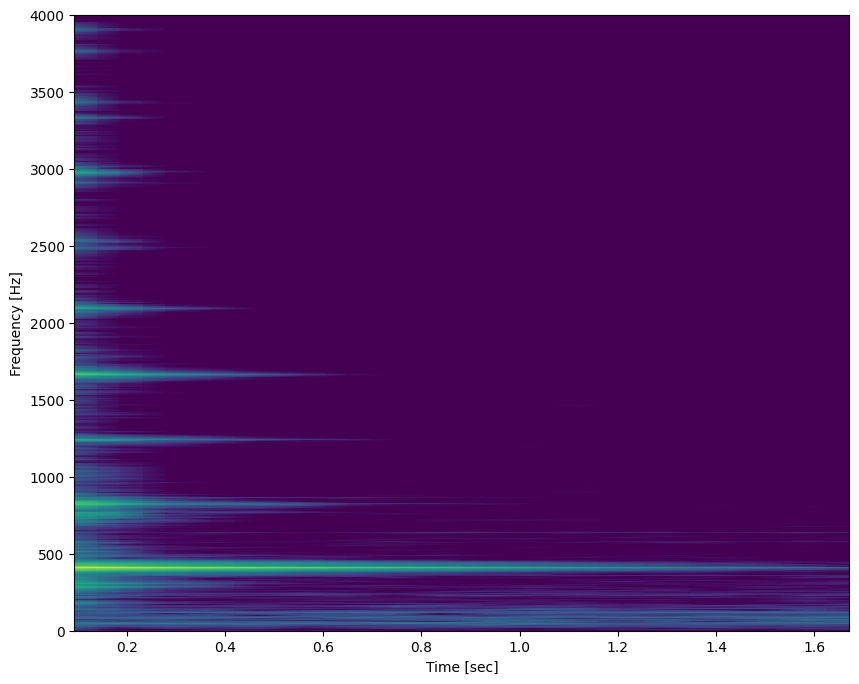

In [50]:
# Write your code here
window_length = 8192
ff, tt, S = signal.spectrogram(ref, fs, nperseg=window_length, noverlap=(window_length/2))
plt.figure(figsize=(10,8))
plot_spectrogram(ff, tt, S)
plt.ylim([0, 4000])
plt.show()



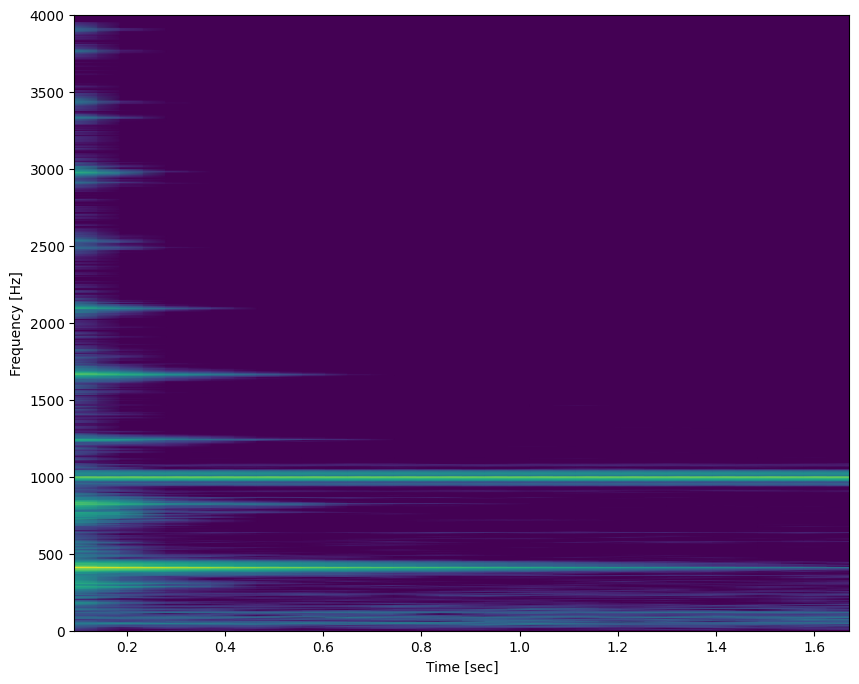

In [51]:
window_length = 8192
ff, tt, S = signal.spectrogram(x_interf, fs, nperseg=window_length, noverlap=(window_length/2))
plt.figure(figsize=(10,8))
plot_spectrogram(ff, tt, S)
plt.ylim([0, 4000])
plt.show()



3.4. Create a function `remove_interference(x, fs)` that applies a nulling filter devised to remove the interference at 1000 Hz. 

Note: remember that a frequency can be converted to the normalized radian frequncy by: $\omega_n = 2\pi f_n/f_s$

In [52]:
def remove_interference(x, fs):
    fn=1000
    wn=2*np.pi*fn/fs
    y = np.convolve(x, [1, -2*np.cos(wn), 1], "same")
    y = np.amax(x)*y/np.amax(y)
    return y
    """Applies nulling filter to remove an interference at 1000 Hz

    Parameters
    ----------
    x : np.array
        The input signal in the form of a numpy array
    fs : int or float
        Frequency rate in Hz

    Returns
    -------
    y : np.array
        The output of the filter

    """
    # Write your code here


3.5 Use the `remove_interference` funcion to clean the corrupted signal,  `x_interf`. Call the output as `x_clean`. Compare the spectrograms of both signals. Explain the result.

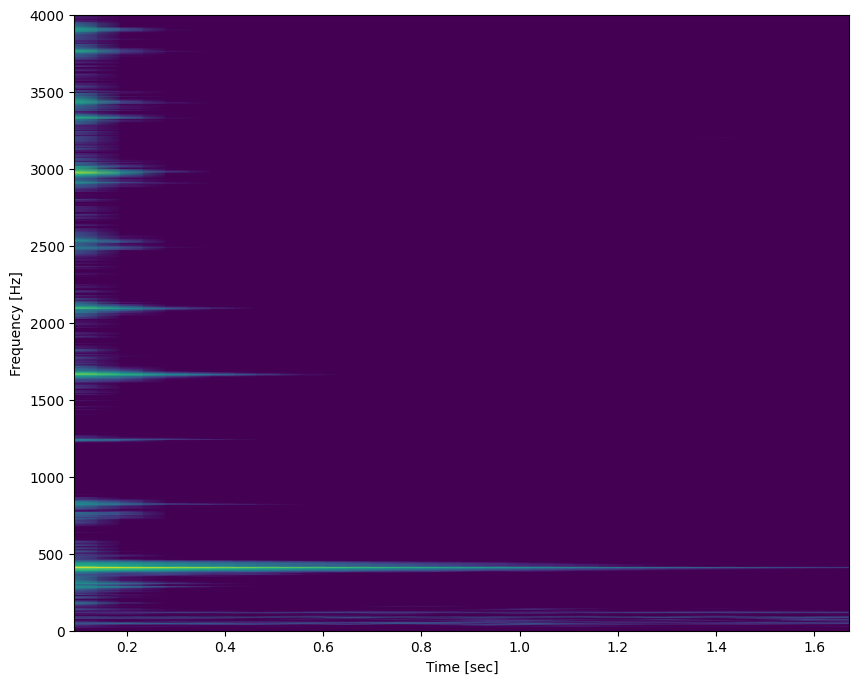

In [ ]:
# Write your code here
x_clean= remove_interference(x_interf, fs)

window_length = 8192
ff, tt, S = signal.spectrogram(x_clean, fs, nperseg=window_length, noverlap=(window_length/2))

plt.figure(figsize=(10,8))
plot_spectrogram(ff, tt, S)
plt.ylim([0, 4000])
plt.show()

By observing at the spectogram, we see how the line that has been added at 1000z now is deleted. That is a clear sign of how we managed to erase the added interfernce. But that came at a clear cost. If we look at the spectogram of the reference signal, we had components at other frequencies. The process to delete the interference had a secondary effect, loosing some information of the original sound. But yes, the interference is now deleted

In [56]:
Audio(ref, rate=fs)

In [58]:
Audio(x_interf
, rate=fs)

In [57]:
Audio(x_clean, rate=fs)